# Flight Delay Training Pipeline Walkthrough

This notebook shows the training pipeline step by step. It is meant for team members who want to understand what happens without reading all Python modules first.

Goal: classify the departure delay into four classes two hours before departure:

- `no_delay`: delay <= 15 minutes
- `small_delay`: 15 minutes < delay <= 1 hour
- `medium_delay`: 1 hour < delay <= 3 hours
- `large_delay`: delay > 3 hours


## 1. Setup

Run this notebook from the `pipeline/` folder.

In Colab, mount Drive and set `DATA_ROOT` below. If imports fail in Colab, install the needed packages once:

```python
%pip install pandas numpy scikit-learn pyarrow s3fs joblib
```


In [1]:
from pathlib import Path
import os
import sys
import importlib
import pandas as pd
from dotenv import load_dotenv
load_dotenv()

# Make local imports work when the notebook is opened from another folder.
PIPELINE_DIR = Path.cwd()
if not (PIPELINE_DIR / 'loader.py').exists():
    PIPELINE_DIR = Path.cwd() / 'pipeline'

if str(PIPELINE_DIR) not in sys.path:
    sys.path.append(str(PIPELINE_DIR))

from loader import LoaderStorage
from targets import add_delay_class_target, DELAY_CLASS_ORDER
from split import chronological_train_val_test_split
from features import build_feature_matrix, fit_transform, transform, check_columns
from evaluate import evaluate_classifier, classification_report_frame, f1_macro_score, plotConfusionMatrix
from train import TrainingConfig, run_training
import models
importlib.reload(models)
from models import make_model,make_neural_network_model, get_feature_importances, plot_feature_importances


I0000 00:00:1778762602.817921   46290 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778762602.865473   46290 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778762603.839619   46290 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
from models import make_model,make_neural_network_model, get_feature_importances, plot_feature_importances


## 2. Configuration

Only change this cell for normal usage.

Examples:

- Colab/Drive: `DATA_ROOT = "/content/drive/MyDrive/Datamining"`
- S3: `DATA_ROOT = "s3://data-mining"`
- Local folder: `DATA_ROOT = "."`


In [3]:
# Change these paths to your actual dataset location.
DATA_ROOT = "s3://data-mining"
INPUT_PATH = 'data/features/j_all_feature_engineered.parquet'

# Column names used by the current pipeline.
DELAY_COLUMN = 'ArrDelayMinutes'
TIME_COLUMN = 'CRSDepDateTime_UTC'
TARGET_COLUMN = 'delay_class'

# Use a small sample while learning/debugging. Set to 1.0 for the final run.
SAMPLE_FRAC = 1.0

# Good first choices: 'dummy', 'logistic_regression', 'random_forest', 'hist_gradient_boosting', xgboost.
MODEL_NAME = 'hist_gradient_boosting'

OUTPUT_DIR = 'outputs/training_notebook'


## 3. Load The Data

`LoaderStorage` hides whether the file is loaded from local disk, Google Drive, or S3. The rest of the notebook can use the same code for all three.


In [4]:
storage = LoaderStorage(DATA_ROOT)

if INPUT_PATH.endswith('.parquet'):
    df = storage.read_parquet(INPUT_PATH)
elif INPUT_PATH.endswith('.csv'):
    df = storage.read_csv(INPUT_PATH)
else:
    raise ValueError('Use a .parquet or .csv dataset.')

if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=42)

print(f'Rows: {len(df):,}')
print(f'Columns: {len(df.columns):,}')
df.head()


Rows: 13,740,088
Columns: 70


,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,Reporting_Airline,Origin,Dest,ArrDelayMinutes,CRSElapsedTime,...,hist_dest_delay_7d,hist_dest_delay_30d,origin_yesterday_delay,origin_lastweek_delay,dest_yesterday_delay,dest_lastweek_delay,airline_yesterday_delay,airline_lastweek_delay,global_yesterday_delay,global_lastweek_delay
0,425849,2014,1,1,3,DL,PHX,DTW,0.0,218.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,428286,2014,1,1,3,DL,SLC,ATL,0.0,207.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,407750,2014,1,1,3,B6,DEN,JFK,0.0,212.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,429330,2014,1,1,3,DL,DEN,ATL,0.0,158.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,366498,2014,1,1,3,AA,SFO,DFW,2.0,195.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Create The Target Classes

The raw delay in minutes is converted into the four interval classes. After this step, the model predicts `delay_class`, not the exact number of minutes.


In [5]:
df = add_delay_class_target(
    df,
    delay_column=DELAY_COLUMN,
    target_column=TARGET_COLUMN,
)

# Show the class balance. This is important because large delays are usually rare.
class_distribution = (
    df[TARGET_COLUMN]
    .value_counts()
    .reindex(DELAY_CLASS_ORDER, fill_value=0)
    .to_frame(name='count')
)

class_distribution['share'] = class_distribution['count'] / len(df)
# expected amount in the test set (20% of the data)
class_distribution['expected_in_test'] = class_distribution['count'] * 0.15
display(class_distribution)

,count,share,expected_in_test
delay_class,,,
no_delay,11098967,0.807780,1664845.05
small_delay,1802071,0.131154,270310.65
medium_delay,705930,0.051377,105889.50
large_delay,133120,0.009688,19968.00


In [6]:
# display all the records, that are in the Large delay class
display(df[df["delay_class"] == 'large_delay'])

,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,Reporting_Airline,Origin,Dest,ArrDelayMinutes,CRSElapsedTime,...,hist_dest_delay_30d,origin_yesterday_delay,origin_lastweek_delay,dest_yesterday_delay,dest_lastweek_delay,airline_yesterday_delay,airline_lastweek_delay,global_yesterday_delay,global_lastweek_delay,delay_class
537,336465,2014,1,1,3,UA,ORD,IAH,299.0,173.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.00000,large_delay
634,334304,2014,1,1,3,UA,LAS,ORD,541.0,217.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.00000,large_delay
1088,428136,2014,1,1,3,DL,MDW,ATL,219.0,107.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.00000,large_delay
1116,334046,2014,1,1,3,UA,ORD,HNL,201.0,551.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.00000,large_delay
1206,389941,2014,1,1,3,AA,ORD,DFW,325.0,150.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.00000,large_delay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13739901,243936,2019,12,31,2,AA,PHX,SAN,572.0,73.0,...,12.694049,13.914676,7.770833,10.466667,9.238994,13.756264,4.4862,13.855747,6.66483,large_delay
13739913,564804,2019,12,31,2,AA,SEA,MIA,644.0,339.0,...,13.300530,16.008097,12.056872,15.671958,4.482353,13.756264,4.4862,13.855747,6.66483,large_delay
13739983,393801,2019,12,31,2,AA,LAX,PHL,763.0,298.0,...,17.086997,12.261845,9.306818,21.410714,6.572464,13.756264,4.4862,13.855747,6.66483,large_delay
13739992,407258,2019,12,31,2,AA,PHX,DTW,491.0,222.0,...,9.142387,13.914676,7.770833,7.672727,3.299145,13.756264,4.4862,13.855747,6.66483,large_delay


In [7]:
# check if all expected Columsn are present, and what unexpected ones we have.
# drop the Unnamed:0 column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
check_columns(df)


## 5. Chronological Train / Validation / Test Split

For a forecasting-like task, we should not randomly mix old and future flights. The model trains on older flights and is evaluated on later flights.

- Train: first 70% of time
- Validation: next 15%
- Test: final 15%


In [8]:
train_df, val_df, test_df = chronological_train_val_test_split(
    df,
    time_column=TIME_COLUMN,
)

print(f'Train rows:      {len(train_df):,}')
print(f'Validation rows: {len(val_df):,}')
print(f'Test rows:       {len(test_df):,}')

pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'start': [train_df[TIME_COLUMN].min(), val_df[TIME_COLUMN].min(), test_df[TIME_COLUMN].min()],
    'end': [train_df[TIME_COLUMN].max(), val_df[TIME_COLUMN].max(), test_df[TIME_COLUMN].max()],
    'rows': [len(train_df), len(val_df), len(test_df)],
})
# drop the time column to avoid data leakage. We will use it later to check the chronological order of the splits.
train_df = train_df.drop(columns=[TIME_COLUMN])
val_df = val_df.drop(columns=[TIME_COLUMN])
test_df = test_df.drop(columns=[TIME_COLUMN])

Train rows:      9,618,061
Validation rows: 2,061,013
Test rows:       2,061,014


## 6. Build Features

This step separates `X` and `y`:

- `X`: the input columns the model is allowed to use
- `y`: the delay class the model should learn to predict

The helper also drops obvious leakage columns like actual delay, actual departure time, actual arrival time, etc.


In [9]:
X_train, y_train = fit_transform(train_df, scale="minmax") # alternatively "standard"
X_val, y_val = transform(val_df)
X_test, y_test = transform(test_df)



print(f'Number of model features: {len(X_train.columns):,}')
X_train.head()
# plot a cross correlation matrix of the features

# for every picture, save a violin plot of the feature distribution for each class


Number of model features: 133


,Year,Month,DayofMonth,DayOfWeek,CRSElapsedTime,Distance,DistanceGroup,CRSDepDateTime,CRSArrDateTime,DayOfYear,...,Dest_ORD,Dest_PDX,Dest_PHL,Dest_PHX,Dest_SAN,Dest_SEA,Dest_SFO,Dest_SLC,Dest_STL,Dest_TPA
0,2014,1,1,3,218.0,0.324495,7,0.016690,0.252259,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2014,1,1,3,207.0,0.307975,7,0.027121,0.255038,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2014,1,1,3,212.0,0.315317,7,0.029207,0.260598,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2014,1,1,3,158.0,0.228228,5,0.040334,0.234190,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2014,1,1,3,195.0,0.282276,6,0.013213,0.232801,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
y_train.head()

0    0
1    0
2    0
3    0
4    0
Name: delay_class, dtype: int64

## 7. Train A Simple Baseline

Always train a baseline first. If a complex model does not beat this, something is wrong or the features are weak.


In [11]:
baseline = make_model('dummy')
baseline.fit(X_train, y_train)

baseline_metrics, baseline_predictions = evaluate_classifier(baseline, X_test, y_test)
display(pd.Series(baseline_metrics, name='baseline_validation_metrics'))

class_distribution = (
    y_train
    .value_counts()
    .to_frame(name='count')
)
display(class_distribution)

F1-macro: 0.2229


accuracy             0.804468
balanced_accuracy    0.250000
macro_f1             0.222910
weighted_f1          0.717296
Name: baseline_validation_metrics, dtype: float64

,count
delay_class,
0,7806258
1,1253166
2,474279
3,84358


In [12]:
baseline = make_model('Baseline')
baseline.fit(X_train, y_train)

baseline_metrics, baseline_predictions = evaluate_classifier(baseline, X_test, y_test)
pd.Series(baseline_metrics, name='baseline_validation_metrics')


Distribution of predicted classes based on the 2h_prev_avg_delay_so_far_day feature:
2h_prev_avg_delay_so_far_day
0    9254082
1     353746
2      10071
3        162
Name: count, dtype: int64
F1-macro: 0.2529


accuracy             0.789559
balanced_accuracy    0.262797
macro_f1             0.252898
weighted_f1          0.727562
Name: baseline_validation_metrics, dtype: float64

## 8. Train The Selected Model

Now train the model chosen in the configuration cell. For large datasets, start with a small sample and only later set `SAMPLE_FRAC = 1.0`.


In [13]:
import inspect
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
import numpy as np



weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(weights))
class_weight_dict = {0: 0.25,
                     1: 0.75,
                     2: 1.0,
                     3: 1.25}
sample_weights = compute_sample_weight(class_weight=class_weight_dict, y=y_train)

model = make_model(MODEL_NAME)
# fit_model_with_class_weights(model, X_train, y_train)

model.fit(X_train, y_train,sample_weight=sample_weights)
val_metrics, val_predictions = evaluate_classifier(model, X_test, y_test)
pd.Series(val_metrics, name=f'{MODEL_NAME}_validation_metrics')


F1-macro: 0.5054


accuracy             0.811736
balanced_accuracy    0.476270
macro_f1             0.505418
weighted_f1          0.800492
Name: hist_gradient_boosting_validation_metrics, dtype: float64

In [14]:
# model = make_neural_network_model(input_shape=X_train.shape[1], num_classes=len(DELAY_CLASS_ORDER))
# # fit_model_with_class_weights(model, X_train, y_train)
# hist =model.fit(X_train, y_train, epochs=5, batch_size=256, validation_data=(X_val, y_val),sample_weight=sample_weights,shuffle=True)
# f1_macro = f1_macro_score(model, X_val, y_val)
# print(f"Validation f1-macro score: {f1_macro:.4f}")
# val_metrics, neuralNetwork_predictions = evaluate_classifier(model, X_test, y_test)
# pd.Series(val_metrics, name=f'NN_validation_metrics')

# # plot the training history
# import matplotlib.pyplot as plt
# fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# hist_df = pd.DataFrame(hist.history)
# axes[0].plot(hist.history["loss"], label="Training Loss")
# axes[0].plot(hist.history["val_loss"], label="Validation Loss")
# axes[0].set_xlabel("Epoch")
# axes[0].set_ylabel("Loss")
# axes[0].legend()



# axes[1].plot(hist.history["f1_score"], label="Training F1-Score")
# axes[1].plot(hist.history["val_f1_score"], label="Validation F1-Score")
# axes[1].set_xlabel("Epoch")
# axes[1].set_ylabel("F1-Score")
# axes[1].legend()

# axes[2].plot(hist.history["accuracy"], label="Training Accuracy")
# axes[2].plot(hist.history["val_accuracy"], label="Validation Accuracy")
# axes[2].set_xlabel("Epoch")
# axes[2].set_ylabel("Accuracy")
# axes[2].legend()
# plt.tight_layout()
# plt.show()

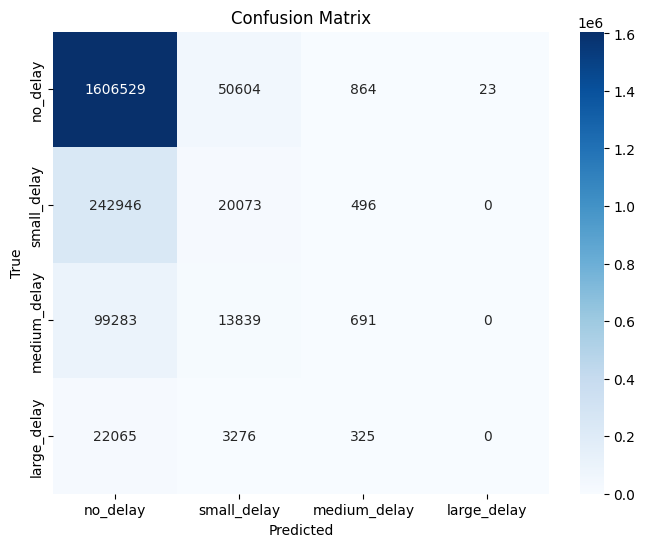

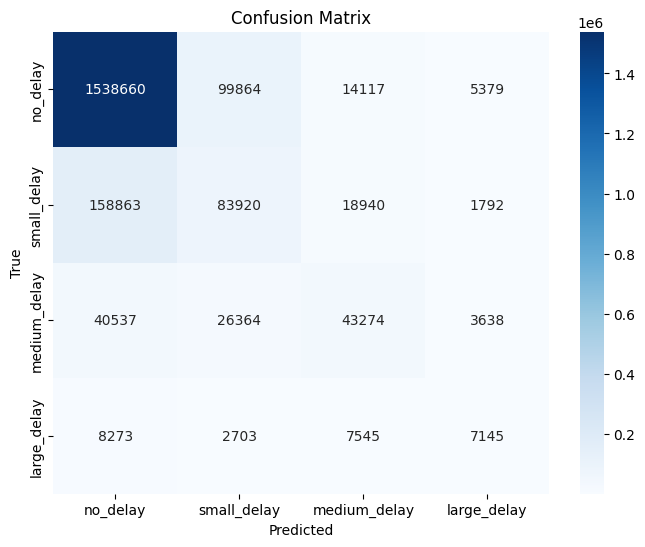

In [15]:
# plot baseline confusion matrix
plotConfusionMatrix(predictions=baseline_predictions, y_true=y_test)
plotConfusionMatrix(predictions=val_predictions, y_true=y_test)


Model type not supported for feature importance


IndexError: index 0 is out of bounds for axis 0 with size 0

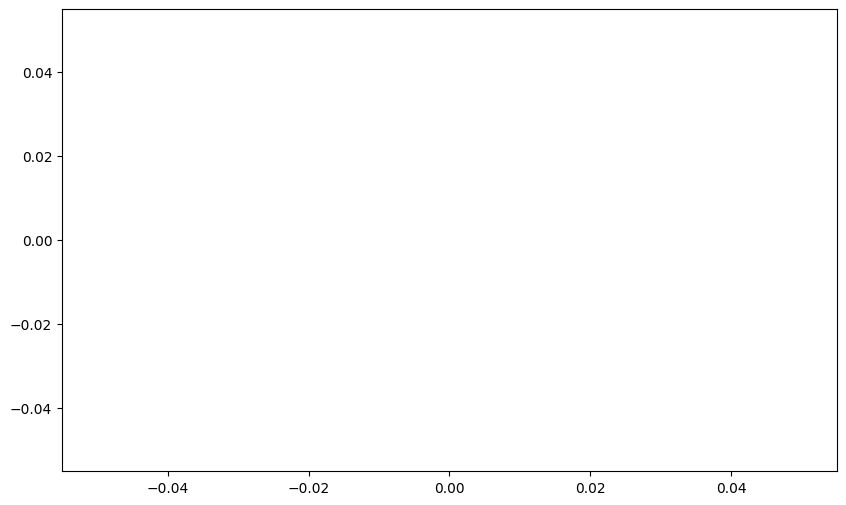

In [16]:
# get the feature importances for the model and plot them
feature_importances = get_feature_importances(model, feature_names=X_train.columns)
# plot the feature importances
plot_feature_importances(feature_importances, top_n=30)
display(feature_importances.head(30))

In [ ]:
test_metrics = evaluate_classifier(model, X_test, y_test)
pd.Series(test_metrics, name=f'{MODEL_NAME}_test_metrics')

## 9. Final Test Evaluation

Only use the test set after choosing a model. This gives the honest final estimate for the report.


In [ ]:
test_metrics = evaluate_classifier(model, X_test, y_test)
pd.Series(test_metrics, name=f'{MODEL_NAME}_test_metrics')


In [ ]:
# Per-class report. Look especially at recall for medium_delay and large_delay.
classification_report_frame(model, X_test, y_test)


## 10. Persist Run Information

Run this cell at the end of every training run. It writes a timestamped JSON file with the configuration, split sizes, model parameters, metrics, and feature importance summary.


In [ ]:
from datetime import datetime, timezone
import joblib
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def make_json_safe(value):
    if isinstance(value, dict):
        return {str(key): make_json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [make_json_safe(item) for item in value]
    if isinstance(value, pd.Series):
        return make_json_safe(value.to_dict())
    if isinstance(value, pd.DataFrame):
        return make_json_safe(value.to_dict(orient="index"))
    if isinstance(value, np.ndarray):
        return make_json_safe(value.tolist())
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    if hasattr(value, "isoformat"):
        return value.isoformat()
    try:
        json.dumps(value)
        return value
    except TypeError:
        return str(value)

def save_confusion_matrix_image(predictions, y_true, path, title):
    cm = confusion_matrix(y_true=y_true, y_pred=predictions, labels=range(len(DELAY_CLASS_ORDER)))
    fig, ax = plt.subplots(figsize=(8, 6))
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=DELAY_CLASS_ORDER)
    display.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)

def save_feature_importance_image(feature_importances, path, top_n=30):
    fig, ax = plt.subplots(figsize=(10, 6))
    feature_importances.head(top_n).plot(kind="barh", ax=ax)
    ax.invert_yaxis()
    ax.set_xlabel("Importance")
    ax.set_title(f"Top {top_n} Feature Importances")
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)

run_timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
run_id = f"{run_timestamp}_{MODEL_NAME}"
run_dir = Path(OUTPUT_DIR) / "runs" / run_id
run_dir.mkdir(parents=True, exist_ok=True)
images_dir = run_dir / "images"
images_dir.mkdir(parents=True, exist_ok=True)

run_val_metrics, run_val_predictions = evaluate_classifier(model, X_val, y_val)
run_test_metrics, run_test_predictions = evaluate_classifier(model, X_test, y_test)
run_classification_report = classification_report_frame(model, X_test, y_test)

try:
    run_feature_importances = get_feature_importances(model, feature_names=X_train.columns).head(30)
except Exception as exc:
    run_feature_importances = {"error": str(exc)}

saved_images = {}
save_confusion_matrix_image(
    run_val_predictions,
    y_val,
    images_dir / "validation_confusion_matrix.png",
    "Validation Confusion Matrix",
)
saved_images["validation_confusion_matrix"] = "images/validation_confusion_matrix.png"
save_confusion_matrix_image(
    run_test_predictions,
    y_test,
    images_dir / "test_confusion_matrix.png",
    "Test Confusion Matrix",
)
saved_images["test_confusion_matrix"] = "images/test_confusion_matrix.png"
if isinstance(run_feature_importances, pd.Series) and not run_feature_importances.empty:
    save_feature_importance_image(run_feature_importances, images_dir / "feature_importances_top_30.png", top_n=30)
    saved_images["feature_importances_top_30"] = "images/feature_importances_top_30.png"

run_info = {
    "run_id": run_id,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "data": {
        "data_root": DATA_ROOT,
        "input_path": INPUT_PATH,
        "sample_frac": SAMPLE_FRAC,
        "target_column": TARGET_COLUMN,
        "delay_column": DELAY_COLUMN,
        "time_column": TIME_COLUMN,
    },
    "splits": {
        "train_rows": len(train_df),
        "validation_rows": len(val_df),
        "test_rows": len(test_df),
    },
    "features": {
        "count": X_train.shape[1],
        "names": list(X_train.columns),
    },
    "target_classes": list(DELAY_CLASS_ORDER),
    "artifacts": {
        "model_path": "model.joblib",
        "run_info_path": "run_info.json",
        "images": saved_images,
    },
    "model": {
        "name": MODEL_NAME,
        "class_name": type(model).__name__,
        "parameters": model.get_params(deep=False) if hasattr(model, "get_params") else {},
        "class_weights": globals().get("class_weight_dict"),
    },
    "metrics": {
        "validation": run_val_metrics,
        "test": run_test_metrics,
        "test_classification_report": run_classification_report,
    },
    "feature_importances_top_30": run_feature_importances,
}

model_path = run_dir / "model.joblib"
joblib.dump(model, model_path)

run_info_path = run_dir / "run_info.json"
run_info_path.write_text(json.dumps(make_json_safe(run_info), indent=2), encoding="utf-8")
print(f"Persisted run folder: {run_dir}")
print(f"Saved model to: {model_path}")
print(f"Saved run information to: {run_info_path}")
print(f"Saved images to: {images_dir}")
run_dir
